# Berlin's Airbnb Market — A SQL Deep-Dive
### 12,855 listings, 12 Bezirke, 138 neighbourhoods · Inside Airbnb Berlin

**Week 5 of my weekly data-science portfolio** &nbsp;·&nbsp; Author: **Pavethran Muthukumaran**

---

Berlin has ~13,000 Airbnb listings, and the surface-level story is boring: "prices vary, Mitte is popular." The interesting story starts one layer down.

This notebook works through the Berlin Airbnb market with **10 progressive SQL queries** — starting with simple aggregations and building up to CTEs, window functions and self-joins. Each answers a real business question, and along the way we uncover three things most tourists and even most analysts miss:

- **The market is nearly half commercial.** Only 54% of listings come from one-listing "genuine" hosts.
- **The pricing paradox:** listings sitting empty all year are *pricier* than the ones actually booked.
- **Two Bezirke rule.** Mitte + Friedrichshain-Kreuzberg = 43% of the whole market.

**Data source:** [Inside Airbnb — Berlin](http://insideairbnb.com/berlin) &nbsp;·&nbsp; **Stack:** SQLite via `pandas.read_sql`, matplotlib for charts.

## Setup

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mt
import seaborn as sns

# Build a fresh in-memory SQLite database from the two CSVs.
# This makes the notebook fully reproducible: just keep the CSVs next to it.
listings       = pd.read_csv("berlin_listings.csv")
neighbourhoods = pd.read_csv("berlin_neighbourhoods.csv")
conn = sqlite3.connect(":memory:")
listings.to_sql("listings", conn, index=False)
neighbourhoods.to_sql("neighbourhoods", conn, index=False)

def q(sql):
    return pd.read_sql(sql, conn)

# palette
INK, TEAL, GOLD, GREEN, RED, SOFT = "#1F3A5F", "#2E86AB", "#F18F01", "#1B7F4B", "#C0392B", "#F4F6FA"
plt.rcParams["figure.dpi"]  = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"]   = 10
sns.set_style("whitegrid")

print(f"Loaded {len(listings):,} listings and {len(neighbourhoods)} neighbourhoods into SQLite.")

Loaded 12,855 listings and 139 neighbourhoods into SQLite.


## The tables

Two tables, joinable on `neighbourhood_group` and `neighbourhood`.

In [2]:
q("SELECT sql FROM sqlite_master WHERE type='table' AND name='listings'")

,sql
0,"CREATE TABLE ""listings"" (\n""id"" INTEGER,\n ""n..."


In [3]:
q("SELECT COUNT(*) AS listings FROM listings"), q("SELECT COUNT(*) AS neighbourhoods FROM neighbourhoods")

(   listings
 0     12855,
    neighbourhoods
 0             139)

## Q1 — How big is the Berlin Airbnb market?

*(basic aggregates + subquery for the median)*

In [4]:
q('''
SELECT COUNT(*)                                              AS total_listings,
       COUNT(DISTINCT host_id)                               AS unique_hosts,
       COUNT(DISTINCT neighbourhood)                         AS neighbourhoods,
       COUNT(DISTINCT neighbourhood_group)                   AS bezirke,
       ROUND(AVG(price), 0)                                  AS avg_price_eur,
       (SELECT price FROM listings
        WHERE price IS NOT NULL
        ORDER BY price
        LIMIT 1 OFFSET (SELECT COUNT(price) FROM listings)/2) AS median_price_eur
FROM listings
''')

,total_listings,unique_hosts,neighbourhoods,bezirke,avg_price_eur,median_price_eur
0,12855,8182,138,12,161.0,131.0


**12,855 listings · 8,182 unique hosts · 138 neighbourhoods across 12 Bezirke.**
Median nightly price = **€131** (mean **€161** — the mean is skewed by a few five-figure luxury listings).

## Q2 — Which Bezirke dominate the market?

*(GROUP BY + calculated percentages via subquery)*

In [5]:
q2 = q('''
SELECT neighbourhood_group AS bezirk,
       COUNT(*)            AS listings,
       ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM listings), 1) AS pct_of_market
FROM listings
GROUP BY neighbourhood_group
ORDER BY listings DESC
''')
q2

,bezirk,listings,pct_of_market
0,Mitte,2865,22.3
1,Friedrichshain-Kreuzberg,2658,20.7
2,Pankow,1950,15.2
3,Charlottenburg-Wilm.,1451,11.3
4,Neukölln,1314,10.2
5,Tempelhof - Schöneberg,855,6.7
6,Treptow - Köpenick,578,4.5
7,Lichtenberg,400,3.1
8,Steglitz - Zehlendorf,356,2.8
9,Reinickendorf,176,1.4


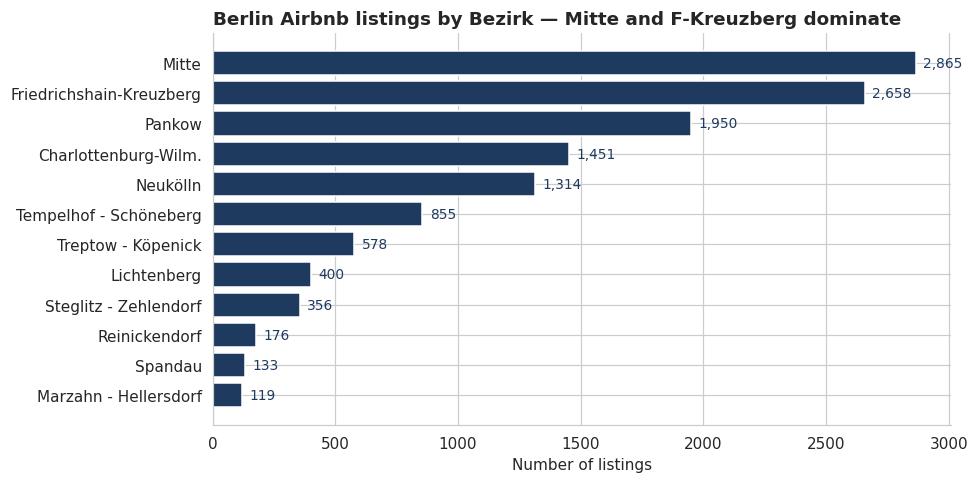

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(q2['bezirk'][::-1], q2['listings'][::-1], color=INK)
for i, v in enumerate(q2['listings'][::-1]):
    ax.text(v + 30, i, f"{v:,}", va='center', fontsize=9, color=INK)
ax.set_title("Berlin Airbnb listings by Bezirk — Mitte and F-Kreuzberg dominate",
             fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel("Number of listings")
sns.despine()
plt.tight_layout()
plt.savefig("chart_bezirke.png", bbox_inches='tight')
plt.show()

**Mitte + Friedrichshain-Kreuzberg alone = 43% of the entire Berlin Airbnb market.** Add Pankow (Prenzlauer Berg lives here) and you're at 58% in three Bezirke.

## Q3 — What does a night in Berlin cost, by room type?

*(WHERE + GROUP BY + multiple aggregates)*

In [7]:
q('''
SELECT room_type,
       COUNT(*)                AS listings,
       ROUND(AVG(price), 0)    AS mean_price,
       MIN(price)              AS min_price,
       MAX(price)              AS max_price
FROM listings
WHERE price IS NOT NULL
GROUP BY room_type
ORDER BY mean_price DESC
''')

,room_type,listings,mean_price,min_price,max_price
0,Hotel room,84,194.0,51.0,524.0
1,Entire home/apt,6138,181.0,3.0,10025.0
2,Private room,2209,105.0,5.0,1145.0
3,Shared room,84,57.0,7.0,300.0


Entire homes lead volume (**6,138** with disclosed price, mean **€181**), private rooms come in at **€105**, shared rooms at **€57**. The **€10,025** max is an outlier — likely a mislabelled monthly rate.

## Q4 — Median price per Bezirk

*(CTE + `ROW_NUMBER()` window function to compute median without a built-in)*

In [8]:
q4 = q('''
WITH ranked AS (
    SELECT neighbourhood_group,
           price,
           ROW_NUMBER() OVER (PARTITION BY neighbourhood_group ORDER BY price) AS rn,
           COUNT(*)     OVER (PARTITION BY neighbourhood_group)                AS cnt
    FROM listings
    WHERE price IS NOT NULL
)
SELECT neighbourhood_group AS bezirk,
       cnt                 AS listings_with_price,
       ROUND(AVG(price), 0) AS median_price
FROM ranked
WHERE rn IN (cnt/2, cnt/2 + 1)
GROUP BY neighbourhood_group, cnt
ORDER BY median_price DESC
''')
q4

,bezirk,listings_with_price,median_price
0,Pankow,1246,153.0
1,Mitte,2038,152.0
2,Friedrichshain-Kreuzberg,1662,139.0
3,Lichtenberg,261,123.0
4,Charlottenburg-Wilm.,1048,119.0
5,Spandau,120,117.0
6,Neukölln,677,116.0
7,Tempelhof - Schöneberg,589,116.0
8,Treptow - Köpenick,406,108.0
9,Steglitz - Zehlendorf,252,99.0


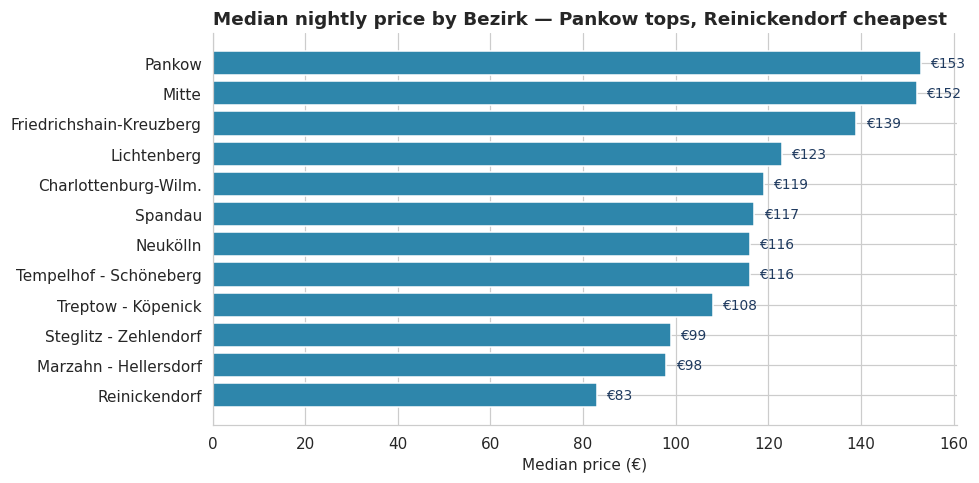

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(q4['bezirk'][::-1], q4['median_price'][::-1], color=TEAL)
for i, v in enumerate(q4['median_price'][::-1]):
    ax.text(v + 2, i, f"€{v:.0f}", va='center', fontsize=9, color=INK)
ax.set_title("Median nightly price by Bezirk — Pankow tops, Reinickendorf cheapest",
             fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel("Median price (€)")
sns.despine()
plt.tight_layout()
plt.savefig("chart_price_by_bezirk.png", bbox_inches='tight')
plt.show()

**Pankow leads at €153 median** (Prenzlauer Berg premium). Mitte close behind at €152. **Reinickendorf, at €83, is 45% cheaper than Pankow** for the same city.

## Q5 — Who's running the biggest operations? (Power hosts)

*(GROUP BY multiple columns + HAVING + LIMIT)*

In [10]:
q('''
SELECT host_name,
       COUNT(*)               AS listings_count,
       ROUND(AVG(price), 0)   AS avg_price,
       SUM(number_of_reviews) AS total_reviews
FROM listings
WHERE host_id IS NOT NULL
GROUP BY host_id, host_name
HAVING COUNT(*) >= 10
ORDER BY listings_count DESC
LIMIT 10
''')

,host_name,listings_count,avg_price,total_reviews
0,Blueground,261,37.0,44
1,Tenitt,199,24.0,19
2,Limehome,103,198.0,4223
3,Vonder,96,24.0,15
4,MAVO Hospitality,57,85.0,434
5,Downtown Apartments,51,235.0,928
6,Downtown Apartments Berlin,50,268.0,641
7,Douglas,44,382.0,2785
8,Singer Hostel Berlin,41,102.0,7034
9,Simon,34,272.0,8434


Ten hosts run **936 listings between them** — 7% of the entire market. **Blueground** alone has **261 listings**. These aren't Berliners renting a spare room — they're professional short-let operators, in some cases entire hotel-alternative brands (Limehome, Singer Hostel).

## Q6 — Which neighbourhoods actually get the most action?

*(GROUP BY + HAVING + calculated `reviews_per_listing`)*

In [11]:
q('''
SELECT neighbourhood,
       neighbourhood_group,
       COUNT(*)                                 AS listings,
       SUM(number_of_reviews)                   AS total_reviews,
       ROUND(SUM(number_of_reviews) * 1.0 / COUNT(*), 1) AS reviews_per_listing
FROM listings
GROUP BY neighbourhood, neighbourhood_group
HAVING COUNT(*) >= 30
ORDER BY reviews_per_listing DESC
LIMIT 10
''')

,neighbourhood,neighbourhood_group,listings,total_reviews,reviews_per_listing
0,Friedrichsfelde Nord,Lichtenberg,34,3241,95.3
1,Schloß Charlottenburg,Charlottenburg-Wilm.,93,8690,93.4
2,Prenzlauer Berg Südwest,Pankow,378,30966,81.9
3,Tempelhofer Vorstadt,Friedrichshain-Kreuzberg,568,44203,77.8
4,Altglienicke,Treptow - Köpenick,30,2311,77.0
5,Prenzlauer Berg Nord,Pankow,179,13665,76.3
6,Regierungsviertel,Mitte,133,10117,76.1
7,Biesdorf,Marzahn - Hellersdorf,37,2811,76.0
8,Moabit Ost,Mitte,232,17626,76.0
9,Alexanderplatz,Mitte,901,67820,75.3


**Reviews-per-listing is the closest proxy we have for actual demand.** Interestingly, Friedrichsfelde Nord (Lichtenberg) and Schloß Charlottenburg lead — both mid-tier neighbourhoods, not the flashy tourist ones. **Alexanderplatz has the highest total reviews (67,820)** — pure volume — but Friedrichsfelde converts more per listing.

## Q7 — The commercial vs. genuine split

*(`CASE WHEN` bucketing over host-listings count)*

In [12]:
q7 = q('''
SELECT
    CASE
      WHEN calculated_host_listings_count = 1 THEN '1 (genuine)'
      WHEN calculated_host_listings_count BETWEEN 2 AND 5 THEN '2-5 (side hustle)'
      WHEN calculated_host_listings_count BETWEEN 6 AND 20 THEN '6-20 (commercial)'
      ELSE '20+ (large operator)'
    END AS host_type,
    COUNT(*)                                             AS listings,
    ROUND(AVG(price), 0)                                 AS avg_price,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM listings), 1) AS pct
FROM listings
WHERE calculated_host_listings_count IS NOT NULL
GROUP BY host_type
ORDER BY MIN(calculated_host_listings_count)
''')
q7

,host_type,listings,avg_price,pct
0,1 (genuine),6890,146.0,53.6
1,2-5 (side hustle),2826,162.0,22.0
2,6-20 (commercial),1706,199.0,13.3
3,20+ (large operator),1354,150.0,10.5


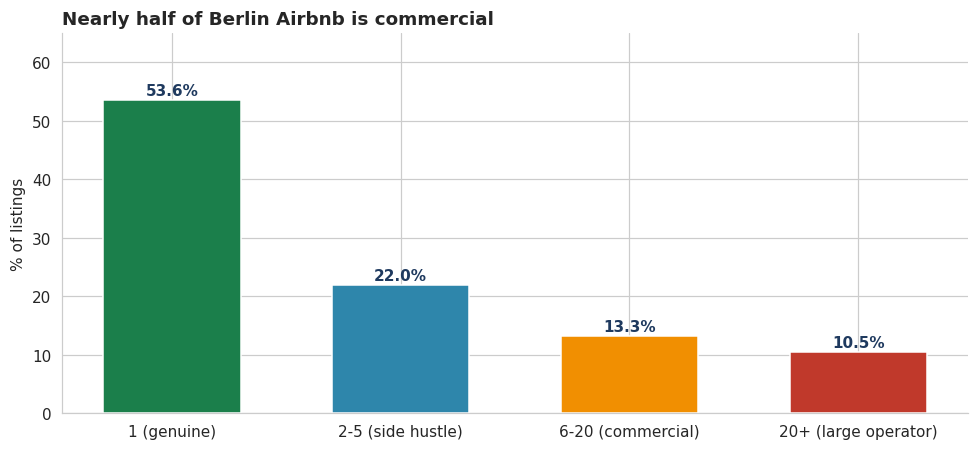

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.2))
colors = [GREEN, TEAL, GOLD, RED]
bars = ax.bar(q7['host_type'], q7['pct'], color=colors, width=0.6)
for b, v in zip(bars, q7['pct']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.8, f"{v:.1f}%", ha='center',
            fontweight='bold', color=INK)
ax.set_title("Nearly half of Berlin Airbnb is commercial",
             fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel("% of listings")
ax.set_ylim(0, 65)
sns.despine()
plt.tight_layout()
plt.savefig("chart_commercial.png", bbox_inches='tight')
plt.show()

**Only 54% of Berlin Airbnb listings are from single-property "genuine" hosts.**
- 22% from side-hustle hosts (2-5 listings)
- 13% from commercial operators (6-20)
- **11% from large operators with 20+ listings** — this alone is 1,354 listings

Commercial and large operators charge higher averages (€199 and €150 vs. €146 for genuine hosts). The market is materially industrialised.

## Q8 — Entire home vs. private room premium by Bezirk

*(CTE + self-JOIN to compare two categories side-by-side)*

In [14]:
q8 = q('''
WITH by_type AS (
    SELECT neighbourhood_group,
           room_type,
           AVG(price) AS avg_price,
           COUNT(*)   AS n
    FROM listings
    WHERE price IS NOT NULL
      AND room_type IN ('Entire home/apt', 'Private room')
    GROUP BY neighbourhood_group, room_type
    HAVING COUNT(*) >= 20
)
SELECT e.neighbourhood_group AS bezirk,
       ROUND(e.avg_price, 0)  AS entire_price,
       ROUND(p.avg_price, 0)  AS private_price,
       ROUND(e.avg_price - p.avg_price, 0)  AS premium_eur,
       ROUND(100.0 * (e.avg_price - p.avg_price) / p.avg_price, 0) AS premium_pct
FROM by_type e
JOIN by_type p
  ON e.neighbourhood_group = p.neighbourhood_group
 AND e.room_type = 'Entire home/apt'
 AND p.room_type = 'Private room'
ORDER BY premium_pct DESC
''')
q8

,bezirk,entire_price,private_price,premium_eur,premium_pct
0,Spandau,294.0,87.0,207.0,238.0
1,Steglitz - Zehlendorf,195.0,73.0,122.0,167.0
2,Treptow - Köpenick,188.0,76.0,113.0,149.0
3,Marzahn - Hellersdorf,147.0,68.0,79.0,116.0
4,Friedrichshain-Kreuzberg,183.0,95.0,88.0,92.0
5,Lichtenberg,174.0,91.0,82.0,90.0
6,Pankow,188.0,103.0,85.0,83.0
7,Tempelhof - Schöneberg,170.0,95.0,75.0,79.0
8,Reinickendorf,117.0,66.0,51.0,78.0
9,Neukölln,152.0,97.0,56.0,58.0


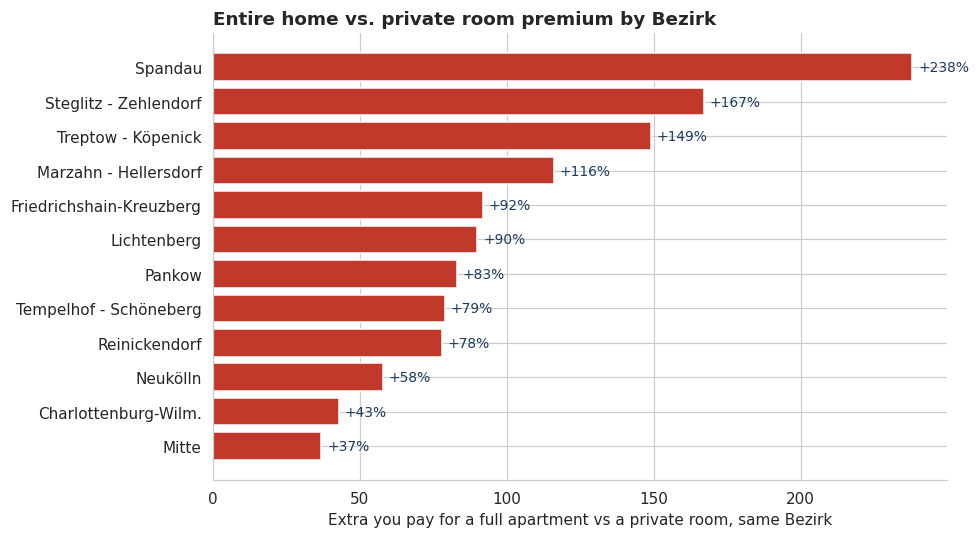

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(q8['bezirk'][::-1], q8['premium_pct'][::-1], color=RED)
for i, v in enumerate(q8['premium_pct'][::-1]):
    ax.text(v + 2, i, f"+{v:.0f}%", va='center', fontsize=9, color=INK)
ax.set_title("Entire home vs. private room premium by Bezirk", fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel("Extra you pay for a full apartment vs a private room, same Bezirk")
sns.despine()
plt.tight_layout()
plt.savefig("chart_premium.png", bbox_inches='tight')
plt.show()

Entire-home premiums range from **+37% in Mitte** to **+238% in Spandau**.
The pattern: in central Bezirke where locals share flats normally, private rooms already command near-apartment prices — small premium.
In outer Bezirke (Spandau, Steglitz, Marzahn), private rooms are cheap and entire homes command a wide premium.

## Q9 — Top 3 neighbourhoods within each Bezirk

*(CTE + `RANK() OVER (PARTITION BY ...)` — classic window function pattern)*

In [16]:
q('''
WITH ranked AS (
    SELECT neighbourhood_group AS bezirk,
           neighbourhood,
           COUNT(*)             AS listings,
           ROUND(AVG(price), 0) AS avg_price,
           RANK() OVER (PARTITION BY neighbourhood_group ORDER BY COUNT(*) DESC) AS rank_in_bezirk
    FROM listings
    WHERE price IS NOT NULL
    GROUP BY neighbourhood_group, neighbourhood
)
SELECT bezirk, neighbourhood, listings, avg_price, rank_in_bezirk
FROM ranked
WHERE rank_in_bezirk <= 3
ORDER BY bezirk, rank_in_bezirk
''')

,bezirk,neighbourhood,listings,avg_price,rank_in_bezirk
0,Charlottenburg-Wilm.,Düsseldorfer Straße,151,144.0,1
1,Charlottenburg-Wilm.,Otto-Suhr-Allee,135,121.0,2
2,Charlottenburg-Wilm.,Kurfürstendamm,133,191.0,3
3,Friedrichshain-Kreuzberg,Frankfurter Allee Süd FK,418,170.0,1
4,Friedrichshain-Kreuzberg,Tempelhofer Vorstadt,362,160.0,2
5,Friedrichshain-Kreuzberg,südliche Luisenstadt,206,149.0,3
6,Lichtenberg,Neu Lichtenberg,66,134.0,1
7,Lichtenberg,Karlshorst,54,128.0,2
8,Lichtenberg,Rummelsburger Bucht,33,208.0,3
9,Marzahn - Hellersdorf,Biesdorf,27,147.0,1


Every Bezirk has its concentration hotspots. Highlights:
- **Mitte**: Alexanderplatz (706 listings), Brunnenstr. Süd (383), Brunnenstr. Nord (170) — the classic tourist corridor.
- **Friedrichshain-Kreuzberg**: Frankfurter Allee Süd (418), Tempelhofer Vorstadt (362) — hipster central.
- **Pankow**: three Prenzlauer Berg neighbourhoods take the top spots.
- **Spandau**: Wilhelmstadt tops with a wild **€476** average price — small n, likely outlier-driven.

## Q10 — The availability paradox

*(`CASE WHEN` over a continuous variable, with cross-tab price)*

In [17]:
q10 = q('''
SELECT
    CASE
      WHEN availability_365 = 0                  THEN '0 - Booked out'
      WHEN availability_365 <= 60                THEN '1-60 - Lightly avail'
      WHEN availability_365 <= 180               THEN '61-180 - Half avail'
      WHEN availability_365 <= 300               THEN '181-300 - Mostly avail'
      ELSE                                             '301-365 - Always avail'
    END AS availability_bucket,
    COUNT(*)               AS listings,
    ROUND(AVG(price), 0)   AS avg_price,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM listings), 1) AS pct
FROM listings
GROUP BY availability_bucket
ORDER BY MIN(availability_365)
''')
q10

,availability_bucket,listings,avg_price,pct
0,0 - Booked out,3492,103.0,27.2
1,1-60 - Lightly avail,1557,161.0,12.1
2,61-180 - Half avail,2253,163.0,17.5
3,181-300 - Mostly avail,2527,149.0,19.7
4,301-365 - Always avail,3026,169.0,23.5


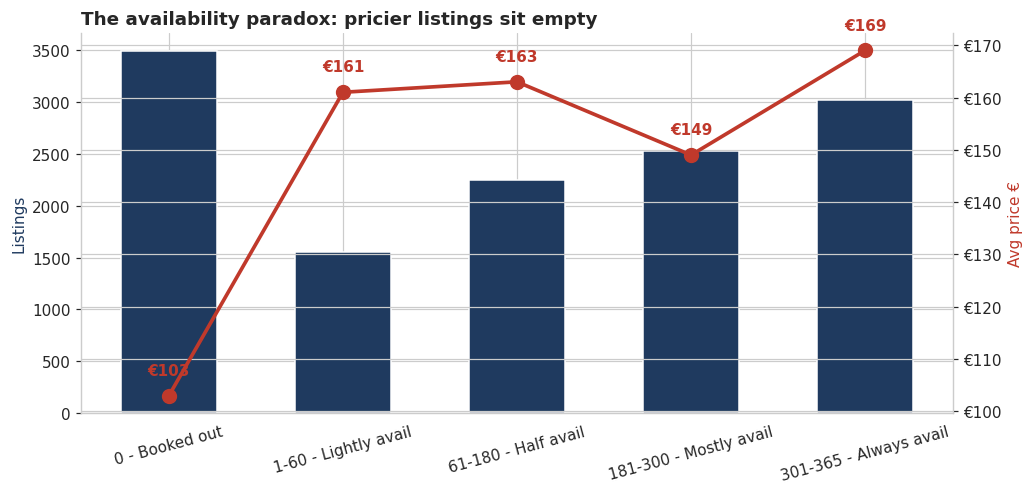

In [18]:
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax2 = ax.twinx()

bars = ax.bar(q10['availability_bucket'], q10['listings'], color=INK, width=0.55, label='Listings')
line, = ax2.plot(q10['availability_bucket'], q10['avg_price'], color=RED, lw=2.4, marker='o',
                 markersize=9, label='Avg price')
for x, v in enumerate(q10['avg_price']):
    ax2.text(x, v + 4, f"€{v:.0f}", ha='center', color=RED, fontweight='bold')

ax.set_title("The availability paradox: pricier listings sit empty",
             fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel("Listings", color=INK)
ax2.set_ylabel("Avg price €", color=RED)
ax2.yaxis.set_major_formatter(mt.FuncFormatter(lambda v, _: f"€{v:.0f}"))
ax.tick_params(axis='x', labelrotation=15)
sns.despine(right=False)
plt.tight_layout()
plt.savefig("chart_availability.png", bbox_inches='tight')
plt.show()

**27% of listings are booked out (0 days available) and average €103.** The **23.5% that are always available** (301-365 days) average **€169** — a **64% higher price for the listings that don't move**.

Two readings, both interesting:
1. Overpricing: hosts asking too much sit empty.
2. Selection: the "always available" bucket is enriched with commercial operators who list at premium regardless of demand.

Either way, if you're a guest, the discount is at the bottom of the availability distribution, not the top.

## Three findings that would surprise most people

> ### 🔎 Finding 1 — Berlin Airbnb is nearly half commercial
> Only **53.6%** of listings come from single-property "genuine" hosts. **46.4%** are from multi-property hosts, including **11% from operators running 20+ listings**. Blueground alone has 261. The postcard image of "someone renting their spare room" describes barely half the market.

> ### 🔎 Finding 2 — Pricier listings sit empty
> Listings with 0 days available (booked out) average **€103**. Listings available all year average **€169** — 64% more. The premium listings aren't rare — they're 23.5% of the market. Whether that's overpricing or commercial holding, the discount is at the bottom of the availability distribution.

> ### 🔎 Finding 3 — Two Bezirke rule
> Mitte + Friedrichshain-Kreuzberg alone = **43% of the market** (5,523 listings). Add Pankow and you cover **58%** in three of twelve Bezirke. Reinickendorf, Spandau, and Marzahn-Hellersdorf combined have less than 4%.

---
## What this notebook demonstrated (SQL-wise)

- **Basic aggregates + subqueries** (Q1, Q2)
- **`GROUP BY` + `HAVING`** (Q3, Q5, Q6)
- **CTEs** (Q4, Q8, Q9)
- **Window functions**: `ROW_NUMBER`, `RANK`, `COUNT() OVER` (Q4, Q9)
- **`CASE WHEN` bucketing** over continuous and count variables (Q7, Q10)
- **Self-JOIN** to compare categories side-by-side (Q8)

Everything running against a local **SQLite** database, executed via `pandas.read_sql`.

---
*Week 5 of my weekly data-science portfolio. Built with SQL (SQLite), Python (pandas, matplotlib).*